# Emerging Technologies - Assessment Problems

This notebook explores the difference between classical and quantum algorithms through five problems centred on the [Deutsch-Jozsa algorithm](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-jozsa-algorithm). The Deutsch-Jozsa algorithm is historically significant as one of the first demonstrations that a quantum computer can solve a well-defined problem exponentially faster than any classical deterministic algorithm.

The problems progress from classical Python to full Qiskit quantum circuits:

1. Generating random Boolean functions
2. Classical algorithm to determine function type
3. Quantum oracles for Deutsch's single-input problem
4. Deutsch's algorithm implemented in Qiskit
5. Generalisation to the full Deutsch-Jozsa algorithm for four-bit inputs

In [4]:
# Standard library: random selections and combinatorics.
import random
import itertools as it

# Quantum computing framework.
# See: https://docs.quantum.ibm.com/
import qiskit

# Quantum circuit simulator.
# See: https://qiskit.github.io/qiskit-aer/
import qiskit_aer as aer

# Quantum state and visualisation utilities.
import qiskit.quantum_info as info
import qiskit.visualization as viz

---

## Problem 1: Generating Random Boolean Functions

### Background

A **Boolean function** with $n$ inputs maps binary strings to a single bit:

$$f : \{0, 1\}^n \to \{0, 1\}$$

The [Deutsch-Jozsa algorithm](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-jozsa-algorithm) is guaranteed that the function is one of two types:

- **Constant**: $f(x) = 0$ for all inputs, or $f(x) = 1$ for all inputs. There are exactly **2** constant functions.
- **Balanced**: $f(x) = 1$ for exactly **half** of all possible inputs. For $n = 4$ inputs ($2^4 = 16$ combinations), exactly 8 outputs must be 1. The number of balanced functions is $\binom{16}{8} = 12{,}870$.

As described in the [IBM Quantum course on classical information](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/single-systems/classical-information#deterministic-operations), Boolean functions form the foundation of both classical and quantum computation.

### Implementation Strategy

The function uses a **lookup table** approach: all $2^4 = 16$ input combinations are precomputed, outputs are assigned (constant or balanced), and the result is returned as a Python **closure**. A closure is an inner function that retains access to variables from its enclosing scope - see [Real Python: Python Closures](https://realpython.com/python-closure/). This makes the function appear opaque to the caller: the type cannot be determined by inspecting the function object, only by evaluating it on inputs.

In [5]:
def random_constant_balanced():
    """Return a randomly chosen constant or balanced function.

    The returned function accepts exactly four Boolean arguments
    and returns 0 or 1.

    Constant: all 16 outputs are 0, or all are 1.
    Balanced: exactly 8 of the 16 outputs are 1.

    Returns:
        f (callable): A function f(a, b, c, d) -> int (0 or 1).
    """
    # Generate every 4-bit input combination: (0,0,0,0), (0,0,0,1), ..., (1,1,1,1).
    # itertools.product with repeat=4 gives 2^4 = 16 tuples.
    all_inputs = list(it.product((0, 1), repeat=4))

    # Randomly select function type with equal probability.
    func_type = random.choice(['constant', 'balanced'])

    if func_type == 'constant':
        # Constant: choose either always-0 or always-1.
        value = random.choice([0, 1])
        lookup = {inp: value for inp in all_inputs}
    else:
        # Balanced: exactly 8 outputs are 1, 8 are 0.
        # Start with an equal split, then shuffle to randomise placement.
        outputs = [0] * 8 + [1] * 8
        random.shuffle(outputs)
        lookup = dict(zip(all_inputs, outputs))

    def f(a, b, c, d):
        """Return f(a, b, c, d) from the precomputed lookup table."""
        return lookup[(a, b, c, d)]

    # Attach the type as metadata 
    f._type = func_type
    return f

### Demonstration

We generate a function and print its full truth table. The `f._type` attribute is attached for testing purposes only - in the real Deutsch-Jozsa scenario the caller has no way to inspect this.

In [6]:
# Generate a random constant-or-balanced function.
f_demo = random_constant_balanced()

# Print the full truth table (16 rows for n=4).
print(f"{'a':>3} {'b':>3} {'c':>3} {'d':>3}  |  f(a,b,c,d)")
print("-" * 32)
for inp in it.product((0, 1), repeat=4):
    print(f"{inp[0]:>3} {inp[1]:>3} {inp[2]:>3} {inp[3]:>3}  |  {f_demo(*inp)}")

  a   b   c   d  |  f(a,b,c,d)
--------------------------------
  0   0   0   0  |  1
  0   0   0   1  |  0
  0   0   1   0  |  0
  0   0   1   1  |  1
  0   1   0   0  |  0
  0   1   0   1  |  0
  0   1   1   0  |  1
  0   1   1   1  |  0
  1   0   0   0  |  1
  1   0   0   1  |  1
  1   0   1   0  |  0
  1   0   1   1  |  1
  1   1   0   0  |  0
  1   1   0   1  |  1
  1   1   1   0  |  1
  1   1   1   1  |  0


In [7]:
# Verify the output distribution.
all_outputs = [f_demo(*inp) for inp in it.product((0, 1), repeat=4)]
ones = sum(all_outputs)

print(f"Number of 1-outputs : {ones} / 16")
print(f"Number of 0-outputs : {16 - ones} / 16")
print(f"Hidden type         : {f_demo._type}")
print(f"Verified type       : {'constant' if ones in (0, 16) else 'balanced'}")

Number of 1-outputs : 8 / 16
Number of 0-outputs : 8 / 16
Hidden type         : balanced
Verified type       : balanced


In [8]:
# Generate several functions to confirm both types appear.
print("Generating 10 random functions:")
for i in range(10):
    g = random_constant_balanced()
    outputs = [g(*inp) for inp in it.product((0, 1), repeat=4)]
    ones_count = sum(outputs)
    verified = 'constant' if ones_count in (0, 16) else 'balanced'
    print(f"  Function {i+1}: ones={ones_count:>2}, type={verified}")

Generating 10 random functions:
  Function 1: ones= 0, type=constant
  Function 2: ones=16, type=constant
  Function 3: ones= 8, type=balanced
  Function 4: ones= 0, type=constant
  Function 5: ones= 0, type=constant
  Function 6: ones= 8, type=balanced
  Function 7: ones= 0, type=constant
  Function 8: ones= 8, type=balanced
  Function 9: ones= 8, type=balanced
  Function 10: ones=16, type=constant


---

## Problem 2: Classical Testing for Function Type

### Classical Query Complexity

**Query complexity** counts how many times an algorithm must call (query) a function $f$ to determine a property. This is the standard model used to compare classical and quantum algorithms - see [IBM Quantum: Deutsch-Jozsa, The Problem](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa#the-problem).

For a classical **deterministic** algorithm solving the constant-vs-balanced problem:

- After $2^{n-1}$ queries that all return the same value, the function could still be balanced (the remaining $2^{n-1}$ inputs could all return the opposite value).
- Only after the $(2^{n-1} + 1)$-th query returning the same value are we 100% certain the function is constant.
- Equivalently, if any two queries return different values, we are immediately certain the function is balanced.

For $n = 4$: **maximum queries needed = $2^3 + 1 = 9$**.

This contrasts with the quantum algorithm (Problem 4), which always uses exactly **1 query** - the central claim of [Deutsch & Jozsa, 1992](https://dl.acm.org/doi/10.5555/895843).

In [9]:
def determine_constant_balanced(f):
    """Determine whether f is constant or balanced.

    Queries f on all possible 4-bit inputs and returns the type.
    Uses early termination: as soon as two different outputs are
    seen, the function must be balanced (given the problem guarantee).

    Args:
        f (callable): A function f(a, b, c, d) -> int (0 or 1),
                      guaranteed to be constant or balanced.

    Returns:
        str: 'constant' or 'balanced'.
    """
    # All 16 possible inputs for n=4.
    all_inputs = list(it.product((0, 1), repeat=4))

    # Query f on the first input to establish a reference output.
    reference = f(*all_inputs[0])
    call_count = 1

    # Query remaining inputs; stop as soon as a differing output is found.
    for inp in all_inputs[1:]:
        output = f(*inp)
        call_count += 1

        # Different output found - must be balanced (problem guarantee).
        if output != reference:
            print(f"  Determined after {call_count} queries (early termination).")
            return 'balanced'

    # All 16 outputs were identical - function is constant.
    print(f"  Determined after {call_count} queries (all outputs identical).")
    return 'constant'

### Demonstration

In [10]:
# Test on 8 randomly generated functions and verify correctness.
print("Testing determine_constant_balanced on 8 random functions:\n")

for i in range(8):
    g = random_constant_balanced()
    expected = g._type  # Metadata attached in Problem 1 (cheating - for testing only).
    print(f"Function {i + 1} (hidden type: {expected}):")
    result = determine_constant_balanced(g)
    match = '✓' if result == expected else '✗'
    print(f"  Result: {result} {match}\n")

Testing determine_constant_balanced on 8 random functions:

Function 1 (hidden type: balanced):
  Determined after 3 queries (early termination).
  Result: balanced ✓

Function 2 (hidden type: balanced):
  Determined after 2 queries (early termination).
  Result: balanced ✓

Function 3 (hidden type: balanced):
  Determined after 2 queries (early termination).
  Result: balanced ✓

Function 4 (hidden type: constant):
  Determined after 16 queries (all outputs identical).
  Result: constant ✓

Function 5 (hidden type: constant):
  Determined after 16 queries (all outputs identical).
  Result: constant ✓

Function 6 (hidden type: balanced):
  Determined after 3 queries (early termination).
  Result: balanced ✓

Function 7 (hidden type: constant):
  Determined after 16 queries (all outputs identical).
  Result: constant ✓

Function 8 (hidden type: balanced):
  Determined after 2 queries (early termination).
  Result: balanced ✓



### Worst-Case Analysis

In [11]:
# Demonstrate the worst case: a constant function requires all 16 queries
# before early termination is impossible (or 9 to be certain).

# Construct the worst-case manually: constant-0 function.
def const_zero_test(a, b, c, d):
    """Constant-0: always returns 0 - classical worst case."""
    return 0

print("Worst case - constant function (all outputs the same):")
result = determine_constant_balanced(const_zero_test)
print(f"Result: {result}")

Worst case - constant function (all outputs the same):
  Determined after 16 queries (all outputs identical).
Result: constant


### Efficiency Summary

| Scenario | Queries needed |
|---|---|
| Best case (balanced, different outputs on first two queries) | 2 |
| Worst case (constant, or balanced with all same outputs until last) | $2^{n-1} + 1 = 9$ |

**Maximum queries for 100% certainty: $2^{n-1} + 1 = 9$.**

The argument is as follows. After observing $2^{n-1}$ identical outputs, we cannot yet distinguish: the remaining $2^{n-1}$ inputs could all return the opposite value (balanced) or the same value (constant). One more query breaks this ambiguity. For a *probabilistic* classical algorithm (allowed to be wrong with some small probability $\varepsilon$), $O(1)$ queries also suffice - a subtlety noted in [Nielsen & Chuang, *Quantum Computation and Quantum Information*](https://www.cambridge.org/highereducation/books/quantum-computation-and-quantum-information/01E10196D0A682A6AEFFEA52D53BE9AE), Chapter 1. The **deterministic** separation is what makes the theorem significant.

---

## Problem 3: Quantum Oracles

### What Is a Quantum Oracle?

A quantum oracle is a unitary (reversible) quantum gate that encodes a classical function $f$ into a quantum circuit. The standard form is the **phase-kickback oracle**:

$$U_f |x\rangle|y\rangle = |x\rangle|y \oplus f(x)\rangle$$

where $\oplus$ is XOR (addition modulo 2). The input register $|x\rangle$ is never modified; the function value is XOR'd into the **ancilla qubit** $|y\rangle$.

This design is required because **all quantum gates must be reversible** - they are unitary matrices. Simply computing $|x\rangle \to |f(x)\rangle$ would generally be irreversible for non-bijective functions. See [IBM Quantum: Quantum Query Algorithms](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-algorithm) for a full treatment.

### The Four Single-Input Boolean Functions

For a single Boolean input $x \in \{0, 1\}$, there are exactly four functions $f : \{0,1\} \to \{0,1\}$:

| Function | $f(0)$ | $f(1)$ | Type | Gate Implementation |
|----------|--------|--------|------|---------------------|
| $f_0$ | 0 | 0 | Constant | None (identity) |
| $f_1$ | 0 | 1 | Balanced | CNOT |
| $f_2$ | 1 | 0 | Balanced | X then CNOT |
| $f_3$ | 1 | 1 | Constant | X on ancilla |

As noted in [IBM Quantum: Deterministic Operations](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/single-systems/classical-information#deterministic-operations), these four are the complete set of single-bit Boolean functions.

### Phase Kickback

When the ancilla qubit is prepared in the state $|{-}\rangle = \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)$, the oracle produces a crucial effect:

$$U_f |x\rangle|{-}\rangle = (-1)^{f(x)} |x\rangle|{-}\rangle$$

The ancilla is unchanged, but the input qubit acquires a **relative phase** of $(-1)^{f(x)}$. This is the mechanism that allows Deutsch's algorithm to distinguish constant from balanced functions in one step.

In [12]:
def colvec(qc):
    """Return the state vector of a circuit as a LaTeX column vector.

    Uses Qiskit's Statevector to compute the state and array_to_latex
    to render it.

    Reference:
        https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.quantum_info.Statevector
        https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.visualization.array_to_latex
    """
    sv = info.Statevector.from_instruction(qc)
    return viz.array_to_latex(sv.data.reshape(-1, 1))

In [13]:
def oracle_f0():
    """Oracle for f0: constant-0 function.

    f0(0) = 0, f0(1) = 0.

    Transformation: |x⟩|y⟩ → |x⟩|y ⊕ 0⟩ = |x⟩|y⟩

    Since f(x) = 0 for all x, XORing 0 into the ancilla leaves it
    unchanged. No gates are needed - this is the identity transformation.

    Returns:
        QuantumCircuit: Empty two-qubit circuit (identity).
    """
    qc = qiskit.QuantumCircuit(2, name='f0: const-0')
    # No gates required: y XOR 0 = y.
    return qc

In [14]:
def oracle_f1():
    """Oracle for f1: identity function (balanced).

    f1(0) = 0, f1(1) = 1.

    Transformation: |x⟩|y⟩ → |x⟩|y ⊕ x⟩

    When x = 0: ancilla unchanged (0 ⊕ 0 = 0).
    When x = 1: ancilla flipped  (y ⊕ 1).

    Implemented with a CNOT gate: control = qubit 0 (x),
    target = qubit 1 (y).

    Reference:
        https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit#cx

    Returns:
        QuantumCircuit: Single CNOT gate.
    """
    qc = qiskit.QuantumCircuit(2, name='f1: identity')
    # CNOT: flip target (qubit 1) when control (qubit 0) is |1⟩.
    qc.cx(0, 1)
    return qc

In [15]:
def oracle_f2():
    """Oracle for f2: NOT function (balanced).

    f2(0) = 1, f2(1) = 0.

    Transformation: |x⟩|y⟩ → |x⟩|y ⊕ (1 - x)⟩ = |x⟩|y ⊕ 1 ⊕ x⟩

    Step 1: X gate flips ancilla unconditionally:  y → y ⊕ 1.
    Step 2: CNOT undoes the flip when x = 1:  y ⊕ 1 → y ⊕ 1 ⊕ x.

    Net result:
      x=0: y ⊕ 1 ⊕ 0 = y ⊕ 1  (ancilla flipped, i.e. f(0)=1).
      x=1: y ⊕ 1 ⊕ 1 = y       (ancilla unchanged, i.e. f(1)=0).

    Returns:
        QuantumCircuit: X gate followed by CNOT.
    """
    qc = qiskit.QuantumCircuit(2, name='f2: NOT')
    # Flip ancilla unconditionally (implements the constant-1 part).
    qc.x(1)
    # CNOT undoes the flip conditionally when x = 1.
    qc.cx(0, 1)
    return qc

In [16]:
def oracle_f3():
    """Oracle for f3: constant-1 function.

    f3(0) = 1, f3(1) = 1.

    Transformation: |x⟩|y⟩ → |x⟩|y ⊕ 1⟩

    Since f(x) = 1 for all x, XORing 1 into the ancilla always
    flips it. A single X gate on the ancilla is sufficient.

    Returns:
        QuantumCircuit: Single X gate on ancilla.
    """
    qc = qiskit.QuantumCircuit(2, name='f3: const-1')
    # Flip ancilla unconditionally: y → y ⊕ 1.
    qc.x(1)
    return qc

### Circuit Diagrams

The four oracle circuits are drawn below. Their simplicity is deliberate - the oracle is a *black box* to the quantum algorithm, but its internal structure must be a valid unitary transformation.

Oracle: f0: const-0


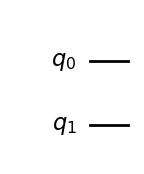


Oracle: f1: identity


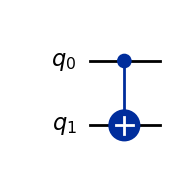


Oracle: f2: NOT


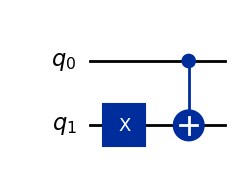


Oracle: f3: const-1


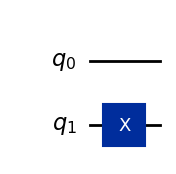

In [17]:
# Draw all four oracle circuits.
for oracle_fn in [oracle_f0, oracle_f1, oracle_f2, oracle_f3]:
    oracle = oracle_fn()
    print(f"Oracle: {oracle.name}")
    display(oracle.draw(output='mpl'))
    print()

### Verification: Truth Table Check

We verify each oracle by initialising the circuit in each of the four computational basis states $|00\rangle$, $|01\rangle$, $|10\rangle$, $|11\rangle$ and observing the output. A correct oracle maps:

$$|x, y\rangle \to |x, y \oplus f(x)\rangle$$

so the input qubit (qubit 0) is always unchanged, and the ancilla (qubit 1) is flipped when $f(x) = 1$.

In [18]:
# Verify each oracle against its expected truth table.
for oracle_fn in [oracle_f0, oracle_f1, oracle_f2, oracle_f3]:
    oracle = oracle_fn()
    print(f"Oracle: {oracle.name}")
    print(f"  {'Input |xy⟩':>12}  {'Output |xy⟩':>13}")

    # Test all four computational basis states.
    for x, y in [(0, 0), (0, 1), (1, 0), (1, 1)]:
        qc = qiskit.QuantumCircuit(2)

        # Prepare the input state |x, y⟩.
        if x:
            qc.x(0)  # Flip qubit 0 to |1⟩ if x = 1.
        if y:
            qc.x(1)  # Flip qubit 1 to |1⟩ if y = 1.

        # Apply the oracle.
        qc.compose(oracle, inplace=True)

        # Read the dominant state from the statevector.
        sv = info.Statevector.from_instruction(qc)
        probs = sv.probabilities_dict()
        output_state = max(probs, key=probs.get)
        output_display = output_state[::-1] 

        print(f"  |{x}{y}⟩  →  |{output_display}⟩")

    print()

Oracle: f0: const-0
    Input |xy⟩    Output |xy⟩
  |00⟩  →  |00⟩


  |01⟩  →  |01⟩
  |10⟩  →  |10⟩
  |11⟩  →  |11⟩

Oracle: f1: identity
    Input |xy⟩    Output |xy⟩
  |00⟩  →  |00⟩
  |01⟩  →  |01⟩
  |10⟩  →  |11⟩
  |11⟩  →  |10⟩

Oracle: f2: NOT
    Input |xy⟩    Output |xy⟩
  |00⟩  →  |01⟩
  |01⟩  →  |00⟩
  |10⟩  →  |10⟩
  |11⟩  →  |11⟩

Oracle: f3: const-1
    Input |xy⟩    Output |xy⟩
  |00⟩  →  |01⟩
  |01⟩  →  |00⟩
  |10⟩  →  |11⟩
  |11⟩  →  |10⟩



---

## Problem 4: Deutsch's Algorithm with Qiskit

### Historical Context

David Deutsch introduced the first quantum algorithm in his landmark 1985 paper ["Quantum Theory, the Church-Turing Principle and the Universal Quantum Computer"](https://www.daviddeutsch.org.uk/wp-content/deutsch85.pdf). The algorithm showed that a quantum computer could solve a specific problem using *fewer* function evaluations than any classical computer - a concrete demonstration of quantum advantage.

### Circuit Structure

The algorithm uses two qubits:

- **Qubit 0** (input/query register): initialised to $|0\rangle$
- **Qubit 1** (ancilla): initialised to $|1\rangle$

```
|0⟩ ──[H]──[           ]──[H]──[Measure]
           |   Oracle   |
|1⟩ ──[H]──[           ]──
```

**Measurement rule:**
- Measure **0** → function is **constant**
- Measure **1** → function is **balanced**

### Step-by-Step State Evolution

Starting from $|0\rangle|1\rangle$:

1. **After H gates:** $|{+}\rangle|{-}\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) \cdot \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)$

2. **After oracle (phase kickback):** $\frac{1}{\sqrt{2}}\left[(-1)^{f(0)}|0\rangle + (-1)^{f(1)}|1\rangle\right]|{-}\rangle$

3. **After final H on qubit 0:**
   - **Constant** ($f(0) = f(1)$): amplitude at $|1\rangle$ is zero → always measure **0**
   - **Balanced** ($f(0) \neq f(1)$): amplitude at $|0\rangle$ is zero → always measure **1**

This is **quantum interference**: amplitudes add constructively or destructively depending on whether the function is constant or balanced. The algorithm exploits quantum parallelism (evaluating $f(0)$ and $f(1)$ simultaneously) plus interference to extract global information in one step. See [IBM Quantum: Deutsch's Algorithm](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-algorithm) for the complete derivation.

In [19]:
def build_deutsch_circuit(oracle):
    """Build Deutsch's algorithm circuit around a given oracle.

    Circuit structure:
        |0⟩ --[X]--[H]--[Oracle]--[H]--[Measure]
        Note: X is omitted on qubit 0; it only sets the ancilla.

        |0⟩ --[H]--[Oracle]--[H]--[Measure]  <- input qubit
        |1⟩ --[H]--[Oracle]--               <- ancilla qubit

    Args:
        oracle (QuantumCircuit): A two-qubit oracle circuit.

    Returns:
        QuantumCircuit: The full Deutsch circuit with measurement.

    Reference:
        https://www.daviddeutsch.org.uk/wp-content/deutsch85.pdf
    """
    # Two qubits, one classical bit for the measurement.
    qc = qiskit.QuantumCircuit(2, 1)

    # Step 1: Set ancilla (qubit 1) to |1⟩.
    qc.x(1)

    # Step 2: Apply Hadamard to both qubits.
    #   Qubit 0: |0⟩ → |+⟩ = (|0⟩ + |1⟩)/√2  (equal superposition)
    #   Qubit 1: |1⟩ → |−⟩ = (|0⟩ - |1⟩)/√2  (phase-kickback ready)
    qc.h(0)
    qc.h(1)

    qc.barrier()

    # Step 3: Apply the oracle - exactly one query.
    qc.compose(oracle, inplace=True)

    qc.barrier()

    # Step 4: Apply Hadamard to input qubit only.
    #   Interference: constant → amplitude at |0⟩; balanced → amplitude at |1⟩.
    qc.h(0)

    # Step 5: Measure the input qubit into classical bit 0.
    qc.measure(0, 0)

    return qc

In [20]:
def run_deutsch(oracle):
    """Run Deutsch's algorithm on the simulator and return the verdict.

    Args:
        oracle (QuantumCircuit): A two-qubit oracle circuit.

    Returns:
        str: 'constant' if measurement is 0, 'balanced' if 1.
    """
    qc = build_deutsch_circuit(oracle)

    # Compile and simulate.
    simulator = aer.AerSimulator()
    compiled = qiskit.transpile(qc, simulator)
    result = simulator.run(compiled, shots=1024).result()
    counts = result.get_counts()

    # The algorithm is deterministic: all shots should give the same result.
    dominant = max(counts, key=counts.get)
    verdict = 'constant' if dominant == '0' else 'balanced'

    return qc, counts, verdict

### Demonstration: All Four Oracles

Circuit for f0: constant-0:


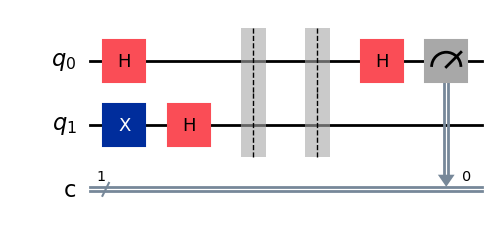


Circuit for f1: identity (balanced):


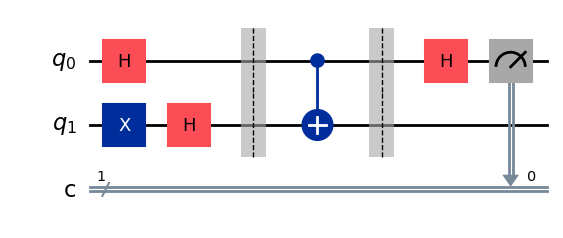


Circuit for f2: NOT (balanced):


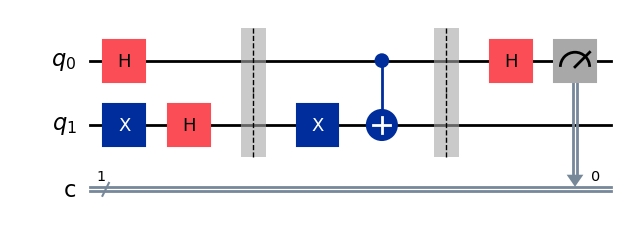


Circuit for f3: constant-1:


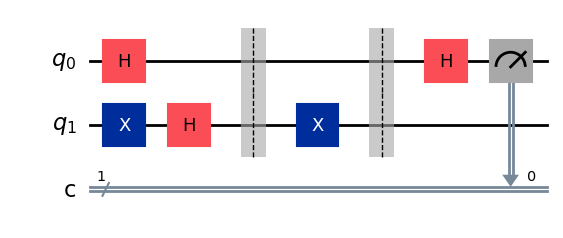

In [21]:
# Draw the Deutsch circuit for each oracle.
oracle_list = [
    (oracle_f0, 'f0: constant-0', 'constant'),
    (oracle_f1, 'f1: identity (balanced)', 'balanced'),
    (oracle_f2, 'f2: NOT (balanced)', 'balanced'),
    (oracle_f3, 'f3: constant-1', 'constant'),
]

for oracle_fn, name, expected in oracle_list:
    oracle = oracle_fn()
    qc = build_deutsch_circuit(oracle)
    print(f"Circuit for {name}:")
    display(qc.draw(output='mpl'))
    print()

In [22]:
# Run Deutsch's algorithm for each oracle and display results.
print(f"{'Oracle':<30} {'Counts':<25} {'Verdict':<12} {'Expected':<12} OK?")
print("-" * 90)

for oracle_fn, name, expected in oracle_list:
    oracle = oracle_fn()
    qc, counts, verdict = run_deutsch(oracle)
    match = '✓' if verdict == expected else '✗'
    print(f"{name:<30} {str(counts):<25} {verdict:<12} {expected:<12} {match}")

Oracle                         Counts                    Verdict      Expected     OK?
------------------------------------------------------------------------------------------


f0: constant-0                 {'0': 1024}               constant     constant     ✓
f1: identity (balanced)        {'1': 1024}               balanced     balanced     ✓
f2: NOT (balanced)             {'1': 1024}               balanced     balanced     ✓
f3: constant-1                 {'0': 1024}               constant     constant     ✓


### State Vector Walkthrough

We trace the state vector step by step for oracle $f_1$ (balanced) to confirm the interference mechanism.

In [24]:
# Trace state vector through each stage of Deutsch's circuit for f1.
qc_trace = qiskit.QuantumCircuit(2)

print("Initial state |00⟩:")
display(colvec(qc_trace))

# Set ancilla to |1⟩.
qc_trace.x(1)
print("After X on qubit 1 → |01⟩:")
display(colvec(qc_trace))

# Apply Hadamard to both.
qc_trace.h(0)
qc_trace.h(1)
print("After H⊗H → |+⟩|−⟩:")
display(colvec(qc_trace))

# Apply oracle f1 (CNOT).
qc_trace.cx(0, 1)
print("After oracle f1 (CNOT) - phase kickback applied:")
display(colvec(qc_trace))

# Final Hadamard on input qubit.
qc_trace.h(0)
print("After final H on qubit 0 - interference collapses to |1⟩|−⟩:")
display(colvec(qc_trace))

Initial state |00⟩:


<IPython.core.display.Latex object>

After X on qubit 1 → |01⟩:


<IPython.core.display.Latex object>

After H⊗H → |+⟩|−⟩:


<IPython.core.display.Latex object>

After oracle f1 (CNOT) - phase kickback applied:


<IPython.core.display.Latex object>

After final H on qubit 0 - interference collapses to |1⟩|−⟩:


<IPython.core.display.Latex object>

### Summary: Interference Pattern

The general formula for the amplitude of $|0\rangle$ in the input register after the final Hadamard is:

$$\text{Amplitude of } |0\rangle = \frac{(-1)^{f(0)} + (-1)^{f(1)}}{2}$$

- **Constant** ($f(0) = f(1)$): the two terms have the **same sign** → sum $= \pm 1$ → probability 1 of measuring **0** (constructive interference).
- **Balanced** ($f(0) \neq f(1)$): the two terms have **opposite signs** → sum $= 0$ → probability 0 of measuring **0** (destructive interference).

This is not a probabilistic algorithm - the result is **certain** regardless of shots. The quantum computer extracts a global property of $f$ (parity of $f(0)$ and $f(1)$) in a single oracle call, which is provably impossible classically.